In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.impute import SimpleImputer
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna

In [5]:
data = pd.read_csv('TD_complete_updated_20241219(in) (1).csv', delimiter=';')

In [ ]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14', 'Feature15', 'Feature16',
       'Feature17', 'Feature18', 'Feature19', 'Feature20', 'Feature21'],
      dtype='object')


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feature1   2782 non-null   int64 
 1   Feature2   2782 non-null   int64 
 2   Feature3   2782 non-null   object
 3   Feature4   2782 non-null   object
 4   Feature5   2764 non-null   object
 5   Feature6   2782 non-null   int64 
 6   Feature7   2782 non-null   int64 
 7   Feature8   2782 non-null   object
 8   Feature9   2782 non-null   object
 9   Feature10  2782 non-null   object
 10  Feature11  2782 non-null   object
 11  Feature12  2782 non-null   object
 12  Feature13  2781 non-null   object
 13  Feature14  2781 non-null   object
 14  Feature15  2782 non-null   object
 15  Feature16  2782 non-null   object
 16  Feature17  2782 non-null   object
 17  Feature18  2782 non-null   object
 18  Feature19  2782 non-null   object
 19  Feature20  2782 non-null   object
 20  Feature21  2782 non-null   int

In [8]:
#data

In [ ]:
target_column = 'Feature21'  

In [10]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'Feature4' column:
['29.04.2021' '27.04.2021' '28.04.2021' '20.04.2023' '10.10.2019'
 '11.10.2019' '13.09.2022' '28.09.2021' '21.10.2021' '14.10.2021'
 '05.10.2021' '04.10.2021' '01.11.2021' '23.09.2021' '06.10.2021'
 '30.09.2021' '22.11.2021' '13.09.2021' '20.09.2021' '08.12.2021'
 '07.10.2021' '12.10.2021' '19.10.2021' '18.10.2021' '20.10.2021'
 '13.10.2021' '11.10.2021' '21.09.2021' '08.09.2021' '16.09.2021'
 '10.06.2021' '14.09.2021' '25.11.2021' '07.09.2021' '09.09.2021'
 '07.12.2021' '10.09.2022' '12.09.2022' '27.09.2021' '06.09.2021'
 '14.11.2022' '17.11.2022' '18.04.2023' '19.04.2023' '15.11.2022'
 '14.12.2022' '16.11.2022' '12.12.2022' '13.12.2022' '15.12.2022'
 '17.04.2023' '18.11.2022']
------------------------------
Distinct values in 'Feature5' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [11]:
data.isnull().sum()

Feature1      0
Feature2      0
Feature3      0
Feature4      0
Feature5     18
Feature6      0
Feature7      0
Feature8      0
Feature9      0
Feature10     0
Feature11     0
Feature12     0
Feature13     1
Feature14     1
Feature15     0
Feature16     0
Feature17     0
Feature18     0
Feature19     0
Feature20     0
Feature21     0
dtype: int64

In [12]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [13]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
[1 0 2]
------------------------------
Distinct values in 'Feature4' column:
[50 46 48 38 13 14 20 49 42 24  2  1  0 44  4 51 43 19 39  9  6 17 37 34
 40 21 15 41  8 29 11 23 45  5 10  7 12 16 47  3 25 32 33 36 27 26 30 18
 22 28 31 35]
------------------------------
Distinct values in 'Feature5' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34 146  80  53   5  41
   2  95 109]
------------------------------
Distinct values in 'Feature

           Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
Feature1   1.000000  0.722170 -0.248724 -0.030774 -0.055235  0.735285   
Feature2   0.722170  1.000000 -0.398860  0.186089  0.057184  0.964872   
Feature3  -0.248724 -0.398860  1.000000 -0.114434 -0.135012 -0.446214   
Feature4  -0.030774  0.186089 -0.114434  1.000000  0.137035  0.110764   
Feature5  -0.055235  0.057184 -0.135012  0.137035  1.000000  0.058584   
Feature6   0.735285  0.964872 -0.446214  0.110764  0.058584  1.000000   
Feature7   0.001778  0.004016 -0.004112  0.009550  0.001191  0.010597   
Feature8  -0.113364 -0.123283  0.067805 -0.007179  0.010246 -0.122699   
Feature9   0.187193  0.337655 -0.332964 -0.026437 -0.069621  0.363959   
Feature10  0.275036  0.299524 -0.036846 -0.069339 -0.158461  0.313540   
Feature11  0.048991  0.118050 -0.182047 -0.066602 -0.032872  0.149878   
Feature12 -0.038444 -0.047293 -0.077940 -0.045851  0.017913 -0.029037   
Feature13  0.173988  0.338432 -0.314239 -0.035659 -

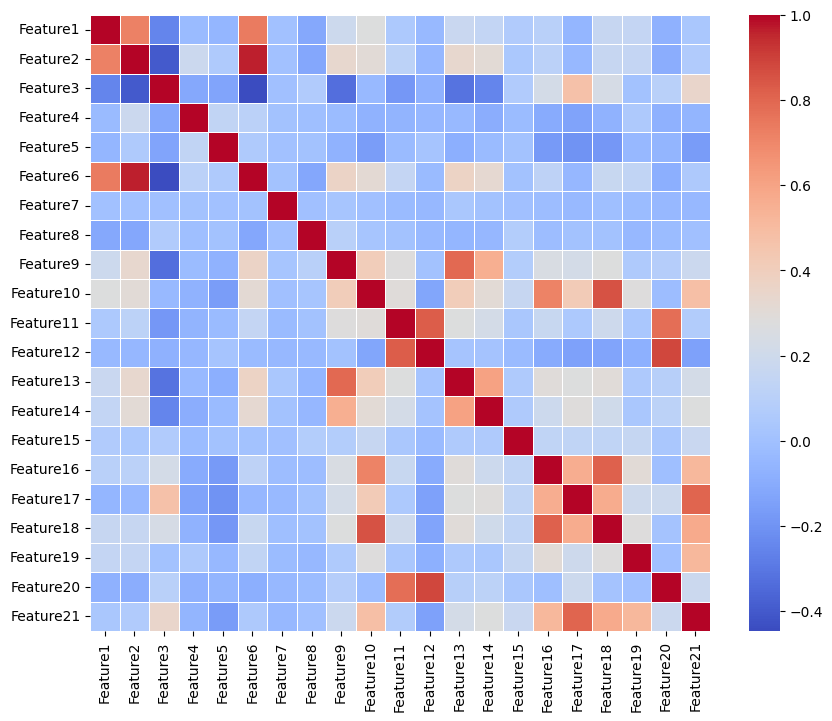

In [14]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

           Feature3  Feature7  Feature8  Feature9  Feature10  Feature11  \
Feature3   1.000000 -0.004112  0.067805 -0.332964  -0.036846  -0.182047   
Feature7  -0.004112  1.000000 -0.001604  0.025057  -0.000298  -0.032471   
Feature8   0.067805 -0.001604  1.000000  0.097695   0.026875   0.011034   
Feature9  -0.332964  0.025057  0.097695  1.000000   0.411067   0.280351   
Feature10 -0.036846 -0.000298  0.026875  0.411067   1.000000   0.289071   
Feature11 -0.182047 -0.032471  0.011034  0.280351   0.289071   1.000000   
Feature12 -0.077940 -0.041777 -0.037984  0.011215  -0.128515   0.827513   
Feature13 -0.314239  0.039171 -0.055425  0.792701   0.409434   0.276586   
Feature14 -0.252652  0.008452 -0.046922  0.556166   0.307696   0.225624   
Feature15  0.066045 -0.000325  0.073721  0.076799   0.161009   0.035267   
Feature20  0.098972 -0.044969 -0.026211  0.080738  -0.017097   0.778677   
Feature21  0.345880 -0.040610 -0.004711  0.184352   0.485169   0.069630   

           Feature12  Fe

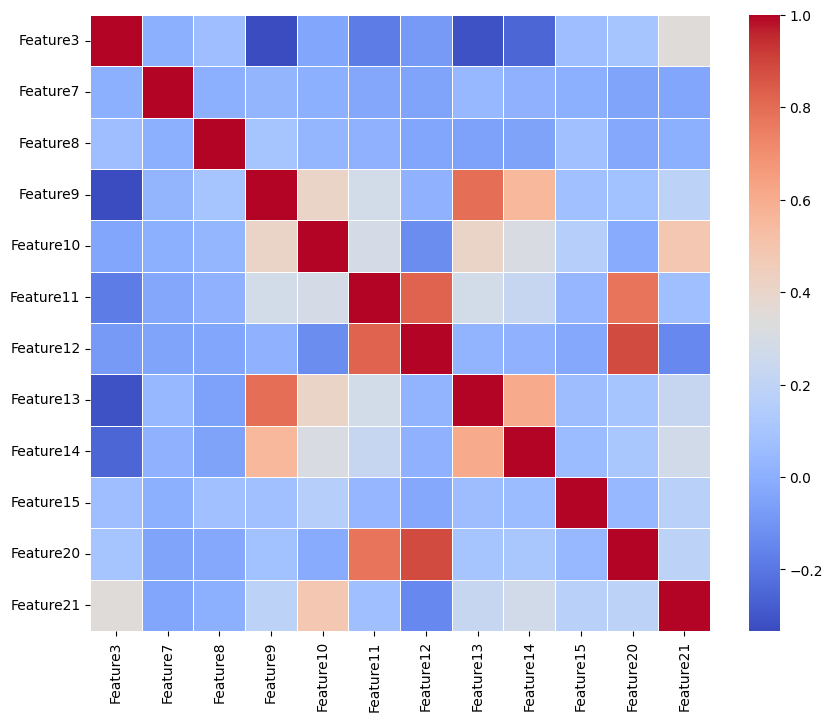

In [ ]:
data_for_analysis = data.drop(['Feature1', 'Feature4', 'Feature5', 'Feature6', 'Feature16', 'Feature17', 'Feature18', 'Feature19', 'Feature2'], axis=1)  
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [16]:
#data_for_analysis

In [ ]:
# Drop rows where 'Feature9' > 4000 and 'Feature10' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['Feature9'] > 4000) & (data_for_analysis['Feature10'] > 5000))]

In [18]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9344\1905939083.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.95124372 3.66356165 4.4308168  ... 4.70048037 4.87519732 4.97673374]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9344\1905939083.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7.6666902  7.38274645 6.27098843 ... 2.30258509 2.77258872 2.56494936]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9344\1905939083.py:10: FutureWarning:

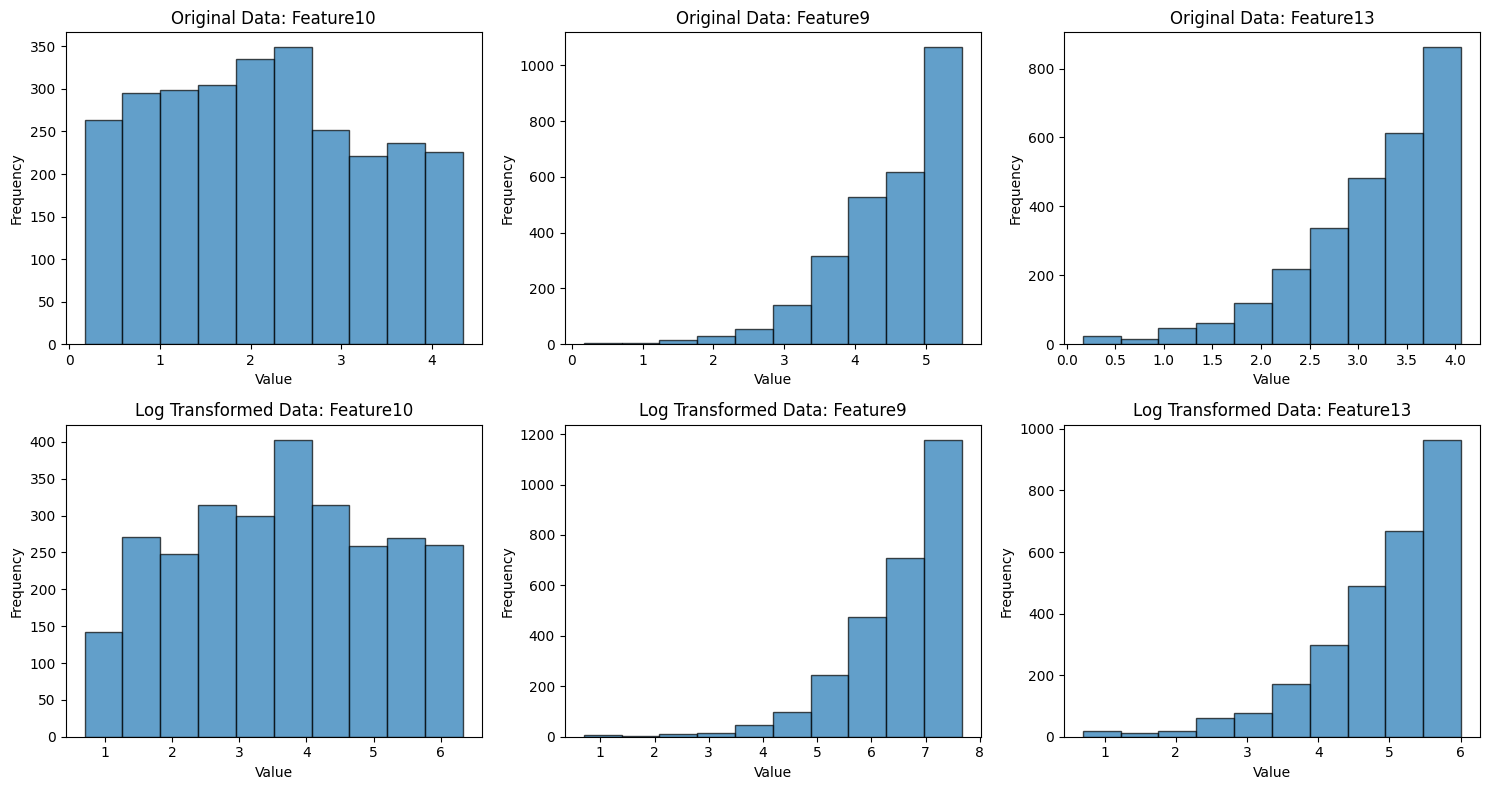

In [19]:
# Define numerical features
numerical_features = ['Feature10', 'Feature9', 'Feature13']

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [20]:
# Standard deviation before scaling
x.std()

Feature3       0.807080
Feature7       0.816699
Feature8       2.974251
Feature9     624.093111
Feature10    132.026334
Feature11    528.339298
Feature12      0.953905
Feature13    115.445135
Feature14    115.474037
Feature15     78.378941
Feature20      2.398766
dtype: float64

In [21]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [22]:
# standard deviation after scaling
x_standardized.std()

Feature3     1.00018
Feature7     1.00018
Feature8     1.00018
Feature9     1.00018
Feature10    1.00018
Feature11    1.00018
Feature12    1.00018
Feature13    1.00018
Feature14    1.00018
Feature15    1.00018
Feature20    1.00018
dtype: float64

In [23]:
x_standardized.columns

Index(['Feature3', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature13', 'Feature14', 'Feature15',
       'Feature20'],
      dtype='object')

#### Semi-Supervised Learning


# Convert target to semi-supervised format (-1 for unlabeled data)
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(30)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

In [24]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

### Let's do a grid search for both models with weighted F1-score

##### Using Grid Search

In [25]:
def run_grid_search(X, y, model_type):
    model = LabelPropagation() if model_type == 'LabelPropagation' else LabelSpreading()

    param_grid = {
        'kernel': ['rbf', 'knn'],
        'gamma': [10, 20, 50, 100]
    }

    if model_type == 'LabelSpreading':  # Only LabelSpreading supports `alpha`
        param_grid['alpha'] = [0.1, 0.3, 0.5, 0.8]

    # Let's define scoring metrics for grid search
    scoring = {'accuracy': 'accuracy', 'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)}

    grid = GridSearchCV(model, param_grid, scoring=scoring, refit='accuracy', cv=3, n_jobs=-1)

    # Filter out unlabeled data points
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    grid.fit(X_labeled, y_labeled)

    # Now save the best estimator and parameters
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_accuracy = grid.best_score_

    return best_params, best_accuracy, best_model

##### Using Optuna

In [26]:
def run_optuna_optimization(X, y, model_type, n_trials=20):
    # Filter labeled data
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    def objective(trial):
        if model_type in ['LabelPropagation', 'LabelSpreading']:
            kernel = trial.suggest_categorical('kernel', ['rbf', 'knn'])
            gamma = trial.suggest_categorical('gamma', [10, 20, 50, 100])
            if model_type == 'LabelPropagation':
                model = LabelPropagation(kernel=kernel, gamma=gamma)
            else:
                alpha = trial.suggest_categorical('alpha', [0.1, 0.3, 0.5, 0.8])
                model = LabelSpreading(kernel=kernel, gamma=gamma, alpha=alpha)
        else:  # Self-Training: using default SVC as base estimator
            base_estimator = SVC(probability=True, gamma='scale')
            model = SelfTrainingClassifier(base_estimator)

        # Evaluate using 3-fold cross-validation on the labeled data
        scores = cross_val_score(model, X_labeled, y_labeled, cv=3, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_trial.params
    best_score = study.best_value

    # Build the best model using the best parameters.
    if model_type in ['LabelPropagation', 'LabelSpreading']:
        if model_type == 'LabelPropagation':
            best_model = LabelPropagation(**best_params)
        else:
            best_model = LabelSpreading(**best_params)
    else:
        best_model = SelfTrainingClassifier(SVC(probability=True, gamma='scale'))

    # Train the best model on the full labeled data.
    best_model.fit(X_labeled, y_labeled)
    return best_params, best_score, best_model

### Progressive Validation 

labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)

    for model_type in ['LabelPropagation', 'LabelSpreading']:
        best_params, best_accuracy, best_model = run_grid_search(x_standardized.to_numpy(), y_semi, model_type)

        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())  # Predict all data points

        # Separate labeled and unlabeled data points
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()  # True values (including labeled and unlabeled)
        
        # Calculate the weighted F1-score on the labeled data only (to compare against true labels)
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)

        results.append({
            'Model': model_type, 
            'Labeled %': perc, 
            'Best Params': best_params, 
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame to display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)


In [27]:
labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)
    
    for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
        best_params, best_accuracy, best_model = run_optuna_optimization(x_standardized.to_numpy(), y_semi, model_type, n_trials=20)
        
        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())
        
        # Only evaluate metrics on the originally labeled data
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)
        
        results.append({
            'Model': model_type,
            'Labeled %': perc,
            'Best Params': best_params,
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

[I 2025-05-07 17:55:21,603] A new study created in memory with name: no-name-efb77fe6-cea0-4159-aeb8-8881ddcb04d1
[I 2025-05-07 17:55:23,373] Trial 0 finished with value: 0.7298192301698613 and parameters: {'kernel': 'rbf', 'gamma': 20}. Best is trial 0 with value: 0.7298192301698613.
[I 2025-05-07 17:55:24,377] Trial 1 finished with value: 0.7334424185756584 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 0 with value: 0.7298192301698613.
[I 2025-05-07 17:55:25,371] Trial 2 finished with value: 0.7262739597942964 and parameters: {'kernel': 'rbf', 'gamma': 100}. Best is trial 2 with value: 0.7262739597942964.
[I 2025-05-07 17:55:25,386] Trial 3 finished with value: 0.7370656069814555 and parameters: {'kernel': 'knn', 'gamma': 10}. Best is trial 2 with value: 0.7262739597942964.
[I 2025-05-07 17:55:25,402] Trial 4 finished with value: 0.7334424185756584 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 2 with value: 0.7262739597942964.
[I 2025-05-07 17:55:25,41

Labeled Data Requirement Results:
                Model  Labeled %  \
0   LabelPropagation        0.1   
1     LabelSpreading        0.1   
2      Self-Training        0.1   
3   LabelPropagation        0.2   
4     LabelSpreading        0.2   
5      Self-Training        0.2   
6   LabelPropagation        0.4   
7     LabelSpreading        0.4   
8      Self-Training        0.4   
9   LabelPropagation        0.6   
10    LabelSpreading        0.6   
11     Self-Training        0.6   
12  LabelPropagation        0.8   
13    LabelSpreading        0.8   
14     Self-Training        0.8   

                                      Best Params  Best Accuracy  \
0                 {'kernel': 'rbf', 'gamma': 100}       0.726274   
1    {'kernel': 'knn', 'gamma': 50, 'alpha': 0.8}       0.650927   
2                                              {}       0.798075   
3                 {'kernel': 'rbf', 'gamma': 100}       0.735561   
4   {'kernel': 'knn', 'gamma': 100, 'alpha': 0.8}       0.712167

#### Let's plot now

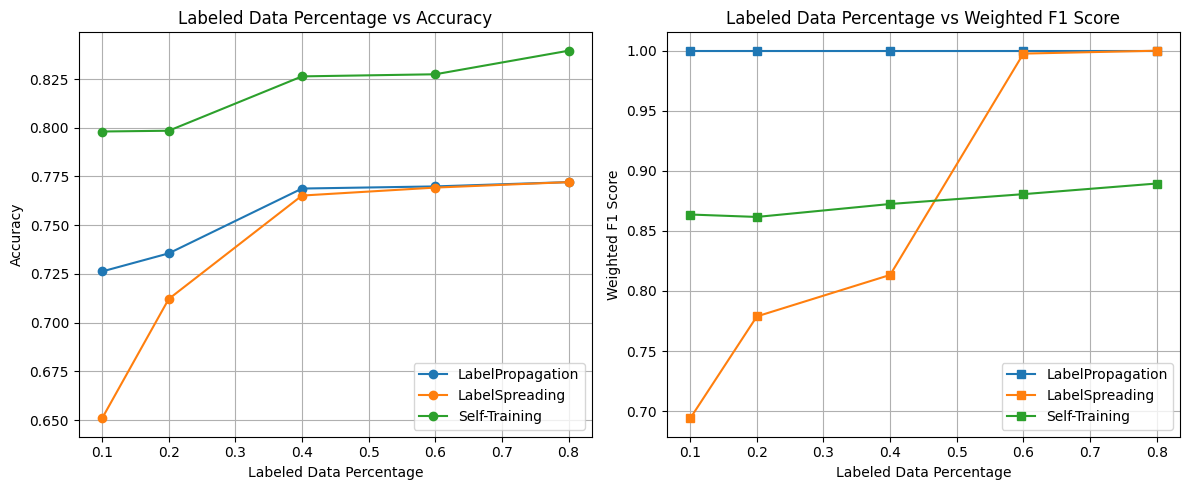

In [28]:
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy vs Labeled Percentage
plt.subplot(1, 2, 1)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Accuracy')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Subplot 2: Weighted F1 Score vs Labeled Percentage
plt.subplot(1, 2, 2)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Weighted F1 Score')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Missing Data

In [29]:
def add_missing_data(X, missing_percentage, column):
    X_missing = X.copy()
    np.random.seed(42)
    total_values = X_missing[column].shape[0]
    n_missing = int(total_values * missing_percentage)
    missing_indices = np.random.choice(X_missing.index, n_missing, replace=False)
    X_missing.loc[missing_indices, column] = np.nan
    return X_missing

In [30]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    y_semi = y.copy()
    total_labels = len(y_semi)
    n_labeled = int(total_labels * label_percentage)
    labeled_indices = np.random.choice(np.arange(total_labels), n_labeled, replace=False)
    y_semi[:] = -1  # Mark all as unlabeled
    y_semi[labeled_indices] = y[labeled_indices]  # Retain true labels for a subset
    return y_semi

#### Run Experiment for Each Column & Missing Percentage

In [ ]:
missing_columns = ['Feature20', 'Feature12']    
missing_percentages = [0.1, 0.2, 0.4]
missing_results = []

for column in missing_columns:
    for perc in missing_percentages:
        # Introduce missing data into one specific column.
        X_missing = add_missing_data(x_standardized, perc, column)
        # Impute missing values.
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X_missing)
        
        # Create semi-supervised labels (e.g., 40% labeled data).
        y_semi = create_semi_supervised_labels(y.to_numpy(), 0.4)
        
        # Loop over the two models.
        for model_type in ['LabelPropagation', 'LabelSpreading']:
            best_params, best_score, best_model = run_optuna_optimization(X_imputed, y_semi, model_type, n_trials=20)
            
            # Predict on the entire dataset.
            y_pred = best_model.predict(X_imputed)
            # Evaluate on the originally unlabeled samples.
            unlabeled_indices = y_semi == -1
            y_true = y.to_numpy()[unlabeled_indices]
            y_pred_unlabeled = y_pred[unlabeled_indices]
            if len(y_true) > 0:
                weighted_f1 = f1_score(y_true, y_pred_unlabeled, average='weighted', zero_division=0)
            else:
                weighted_f1 = np.nan
            
            missing_results.append({
                'Model': model_type,
                'Missing %': perc,
                'Missing Column': column,
                'Best Params': best_params,
                'Best Accuracy': best_score,
                'Weighted F1 Score': weighted_f1
            })

# Convert results to DataFrame.
missing_results_df = pd.DataFrame(missing_results)
print("Fixed Missing Data Results:\n", missing_results_df)

[I 2025-05-07 17:56:13,611] A new study created in memory with name: no-name-cc56a44b-47b4-45e9-93df-609ebb5db8f9
[I 2025-05-07 17:56:13,649] Trial 0 finished with value: 0.7598261334110391 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.7598261334110391.
[I 2025-05-07 17:56:13,696] Trial 1 finished with value: 0.7508341225322357 and parameters: {'kernel': 'rbf', 'gamma': 50}. Best is trial 1 with value: 0.7508341225322357.
[I 2025-05-07 17:56:13,721] Trial 2 finished with value: 0.7598261334110391 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 1 with value: 0.7508341225322357.
[I 2025-05-07 17:56:13,744] Trial 3 finished with value: 0.7598261334110391 and parameters: {'kernel': 'knn', 'gamma': 50}. Best is trial 1 with value: 0.7508341225322357.
[I 2025-05-07 17:56:13,799] Trial 4 finished with value: 0.7553240572108496 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 1 with value: 0.7508341225322357.
[I 2025-05-07 17:56:13,8

Fixed Missing Data Results:
                Model  Missing % Missing Column  \
0   LabelPropagation        0.1      Feature20   
1     LabelSpreading        0.1      Feature20   
2   LabelPropagation        0.2      Feature20   
3     LabelSpreading        0.2      Feature20   
4   LabelPropagation        0.4      Feature20   
5     LabelSpreading        0.4      Feature20   
6   LabelPropagation        0.1      Feature12   
7     LabelSpreading        0.1      Feature12   
8   LabelPropagation        0.2      Feature12   
9     LabelSpreading        0.2      Feature12   
10  LabelPropagation        0.4      Feature12   
11    LabelSpreading        0.4      Feature12   

                                      Best Params  Best Accuracy  \
0                  {'kernel': 'rbf', 'gamma': 50}       0.750834   
1    {'kernel': 'knn', 'gamma': 20, 'alpha': 0.8}       0.735553   
2                 {'kernel': 'rbf', 'gamma': 100}       0.711262   
3    {'kernel': 'rbf', 'gamma': 50, 'alpha': 0.1

#### Plotting

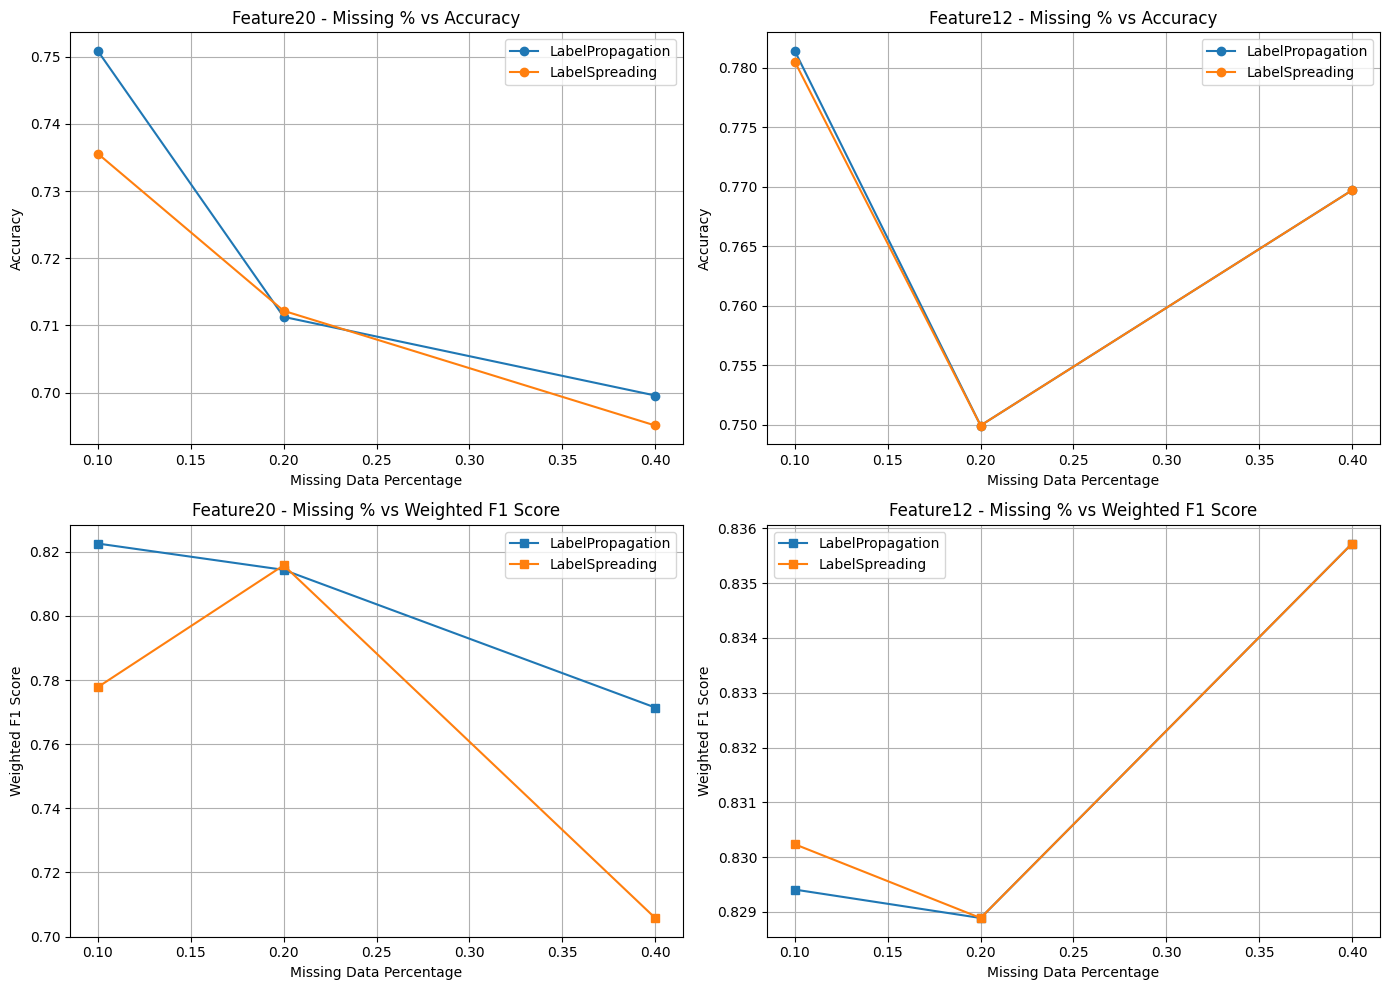

In [32]:
plt.figure(figsize=(14, 10))

for idx, column in enumerate(missing_columns, start=1):
    # Plot Accuracy vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Accuracy')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    
    # Plot Weighted F1 Score vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), len(missing_columns) + idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Weighted F1 Score')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Weighted F1 Score')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()